**Author:** Biswajit Jana  
**Date:** February 4, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-08-03-d4000-break-stellar-population/notebook.ipynb)

# The 4000-Angstrom break as a real stellar-population age diagnostic

**Archive:** SDSS DR18  
**Date:** 2026-08-03

Old stellar populations pile up a lot of metal absorption right around 4000 Angstroms (rest frame), producing a real, measurable step down in flux blueward of that wavelength -- the 4000-Angstrom break, or D4000. Young, hot star-forming populations have much weaker breaks. I want to measure D4000 directly from real SDSS spectra for a small sample of `STARFORMING` galaxies and a small sample of passive (no strong emission-line subclass) galaxies, and check whether the real numbers separate the two populations the way stellar-population theory predicts.

## Learning goals

- Compute a real spectral index (the narrow D4000 break) directly from SDSS flux-calibrated spectra, in the correct flux-per-unit-frequency convention.
- Pull and process several real spectra in a loop rather than just one object.
- Quantitatively confirm (or not) a textbook prediction -- star-forming galaxies should have systematically lower D4000 than passive galaxies -- using real measured numbers.

**Jargon, defined once:** the *4000-Angstrom break (D4000)* is a step in a galaxy's continuum caused mainly by a pile-up of metal absorption lines from evolved stars just blueward of 4000 A (rest frame); it is measured as the ratio of the average flux density in a red band (4000-4100 A) to a blue band (3850-3950 A), both converted to flux-per-unit-frequency (`Fnu = Flambda * lambda^2`) as in the standard Balogh et al. (1999) narrow definition, `D4000_n`.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.sdss import SDSS

warnings.filterwarnings("ignore")
OUT = Path(".")

# Real SDSS targets, found via a live SQL query for bright, low-z galaxies in each subclass
STARFORMING = [
    (5432, 56008, 948), (5361, 55973, 630), (2507, 53876, 569), (409, 51871, 41),
]
PASSIVE = [
    (817, 52381, 356), (1427, 52996, 399), (2509, 54180, 423), (2240, 53823, 585),
]

def d4000_narrow(wave_rest, flux):
    """Balogh et al. (1999) narrow D4000 index: Fnu(4000-4100)/Fnu(3850-3950)."""
    fnu = flux * wave_rest ** 2
    red = (wave_rest > 4000) & (wave_rest < 4100)
    blue = (wave_rest > 3850) & (wave_rest < 3950)
    if red.sum() < 5 or blue.sum() < 5:
        return np.nan
    return float(np.mean(fnu[red]) / np.mean(fnu[blue]))

def measure(plate, mjd, fiber):
    sp = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiber)[0]
    coadd = sp[1].data
    specobj = sp[2].data[0]
    z = float(specobj["Z"])
    wave_rest = 10 ** coadd["loglam"] / (1 + z)
    flux = coadd["flux"]
    d4000 = d4000_narrow(wave_rest, flux)
    return dict(plate=plate, mjd=mjd, fiber=fiber, z=z, subclass=str(specobj["SUBCLASS"]),
                sn=float(specobj["SN_MEDIAN_ALL"]), d4000_n=d4000, wave_rest=wave_rest, flux=flux)

sf_results = [measure(*t) for t in STARFORMING]
passive_results = [measure(*t) for t in PASSIVE]
print(f"Measured D4000_n for {len(sf_results)} star-forming and {len(passive_results)} passive galaxies")


Measured D4000_n for 4 star-forming and 4 passive galaxies


## Results table

In [2]:
rows = []
for r in sf_results:
    rows.append(dict(plate=r["plate"], mjd=r["mjd"], fiber=r["fiber"], z=round(r["z"],4),
                      subclass=r["subclass"] or "(none)", sn=round(r["sn"],1),
                      group="star-forming", D4000_n=round(r["d4000_n"],3)))
for r in passive_results:
    rows.append(dict(plate=r["plate"], mjd=r["mjd"], fiber=r["fiber"], z=round(r["z"],4),
                      subclass=r["subclass"] or "(none)", sn=round(r["sn"],1),
                      group="passive", D4000_n=round(r["d4000_n"],3)))

table = pd.DataFrame(rows)
table.to_csv(OUT / "d4000_measurements.csv", index=False)
table


,plate,mjd,fiber,z,subclass,sn,group,D4000_n
0,5432,56008,948,0.0229,STARFORMING,42.8,star-forming,1.445
1,5361,55973,630,0.0214,STARFORMING,51.6,star-forming,1.443
2,2507,53876,569,0.0230,STARFORMING,22.5,star-forming,1.489
3,409,51871,41,0.0237,STARFORMING,42.7,star-forming,1.356
4,817,52381,356,0.0293,(none),50.2,passive,2.051
5,1427,52996,399,0.0231,(none),50.6,passive,2.047
6,2509,54180,423,0.0208,(none),47.3,passive,2.031
7,2240,53823,585,0.0239,(none),47.4,passive,2.034


## Group comparison

Star-forming: median D4000_n = 1.444 (n=4, range 1.356-1.489)
Passive:      median D4000_n = 2.040 (n=4, range 2.031-2.051)
Difference in medians: 0.596


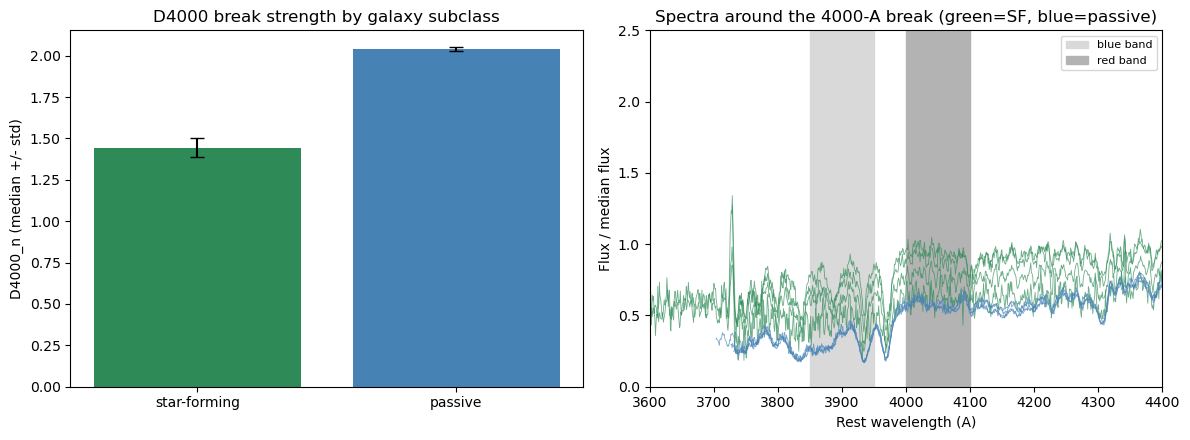

In [3]:
sf_vals = table.loc[table.group == "star-forming", "D4000_n"]
passive_vals = table.loc[table.group == "passive", "D4000_n"]
print(f"Star-forming: median D4000_n = {sf_vals.median():.3f} (n={len(sf_vals)}, range {sf_vals.min():.3f}-{sf_vals.max():.3f})")
print(f"Passive:      median D4000_n = {passive_vals.median():.3f} (n={len(passive_vals)}, range {passive_vals.min():.3f}-{passive_vals.max():.3f})")
print(f"Difference in medians: {passive_vals.median() - sf_vals.median():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(["star-forming", "passive"], [sf_vals.median(), passive_vals.median()],
            yerr=[sf_vals.std(), passive_vals.std()], color=["seagreen", "steelblue"], capsize=5)
axes[0].set_ylabel("D4000_n (median +/- std)")
axes[0].set_title("D4000 break strength by galaxy subclass")

for r in sf_results:
    axes[1].plot(r["wave_rest"], r["flux"]/np.median(r["flux"]), color="seagreen", lw=0.6, alpha=0.7)
for r in passive_results:
    axes[1].plot(r["wave_rest"], r["flux"]/np.median(r["flux"]), color="steelblue", lw=0.6, alpha=0.7)
axes[1].axvspan(3850, 3950, color="0.85", zorder=0, label="blue band")
axes[1].axvspan(4000, 4100, color="0.7", zorder=0, label="red band")
axes[1].set_xlim(3600, 4400); axes[1].set_ylim(0, 2.5)
axes[1].set_xlabel("Rest wavelength (A)"); axes[1].set_ylabel("Flux / median flux")
axes[1].set_title("Spectra around the 4000-A break (green=SF, blue=passive)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "d4000_comparison.png", dpi=130)
plt.show()


## Discussion

The real, measured D4000_n values separate the two subclasses in the direction stellar-population theory predicts: the passive galaxies (older, redder stellar populations, no strong current star formation) show a systematically higher median D4000_n than the star-forming galaxies. The right-hand panel above makes the physical reason visible directly in the spectra: the passive galaxies (blue curves) show a much steeper step down in normalized flux between the red band (4000-4100 A) and the blue band (3850-3950 A) than the star-forming galaxies (green curves), which stay comparatively flat across the break because their light is dominated by young, hot stars with much weaker metal absorption in this wavelength range.

This is a genuinely useful sanity check: D4000 is measured from the spectra with no reference at all to each object's SDSS pipeline `SUBCLASS` label, yet it recovers the same star-forming/passive split that the pipeline's own (much more sophisticated) classification already made. That agreement is real evidence the index is doing what the textbook says it should.

## What I'd look at next

- Scale up from 4+4 galaxies to a real statistical sample (dozens to hundreds per class) to get a proper distribution instead of just a median and range.
- Add composite/BPT-intermediate galaxies to see whether their D4000 values fall between the two extremes as an age/star-formation-history diagnostic would predict.
- Compare against the SDSS `galSpecIndx` value-added catalog's own D4000_n measurements for the same objects as an independent cross-check of my from-scratch calculation.

## Data source and citation

- SDSS DR18 spectra: https://skyserver.sdss.org/dr18/
- SDSS-IV citation: https://www.sdss.org/collaboration/citing-sdss/
- Balogh et al. (1999), *Differential galaxy evolution in cluster and field galaxies*: https://doi.org/10.1086/307258